NIVELL 1
1. Connecta Python amb MySQL Workbench i carrega les dades de la teva base de dades del Sprint 4 per utilitzar-les en tots els exercicis.

In [1]:
import mysql.connector
import pandas as pd

connection = mysql.connector.connect(
    host='localhost',
    database='vendes_bd',
    user='root',
    password='Ciutadella92'
)

cursor = connection.cursor()
cursor.execute("SHOW TABLES")
taules = [t[0] for t in cursor.fetchall()]

dfs = {}

for nom in taules:
    query = f"SELECT * FROM {nom}"
    dfs[nom] = pd.read_sql(query, connection)

connection.close()

C:\Users\Portátil\AppData\Local\Temp\ipykernel_18836\202369306.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  dfs[nom] = pd.read_sql(query, connection)


•	2. Per a cada ítem, crea una visualització adequada segons les variables especificades. Interpreta els resultats segons les teves dades.
Recorda: quan seleccionis les columnes, pensa sempre en el mètode que faràs servir i inclou les que calguin per a la funció de visualització que vulguis utilitzar.
o	Una variable numèrica.
o	Dues variables numèriques.
o	Una variable categòrica.
o	Una variable categòrica i una numèrica.
o	Dues variables categòriques.
o	Tres variables combinades.


In [2]:
df=dfs['products']
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Distribució del pes')

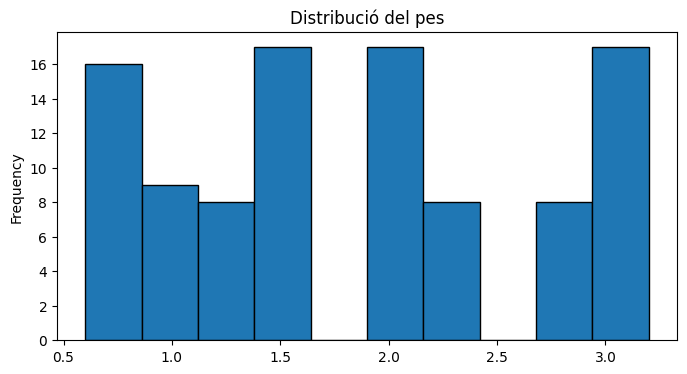

In [3]:
#OK Una variable numèrtica

df['weight'].plot.hist(edgecolor='black', figsize=(8,4))
plt.title('Distribució del pes')

In [4]:
df=dfs['products']
df

,id,product_name,price,colour,weight,warehouse_id
0,1,Direwolf Stannis,161.11,#7c7c7c,1.0,WH-4
1,2,Tarly Stark,9.24,#919191,2.0,WH-3
2,3,duel tourney Lannister,171.13,#d8d8d8,1.5,WH-2
3,4,warden south duel,71.89,#111111,3.0,WH-1
4,5,skywalker ewok,171.22,#dbdbdb,3.2,WH-0
...,...,...,...,...,...,...
95,96,dooku solo,20.92,#282828,2.1,WH--91
96,97,jinn Winterfell,65.25,#bababa,1.0,WH--92
97,98,Direwolf Littlefinger,38.33,#bababa,2.0,WH--93
98,99,the duel,151.78,#212121,1.5,WH--94


Text(0.5, 1.0, 'Relació entre preu i pes')

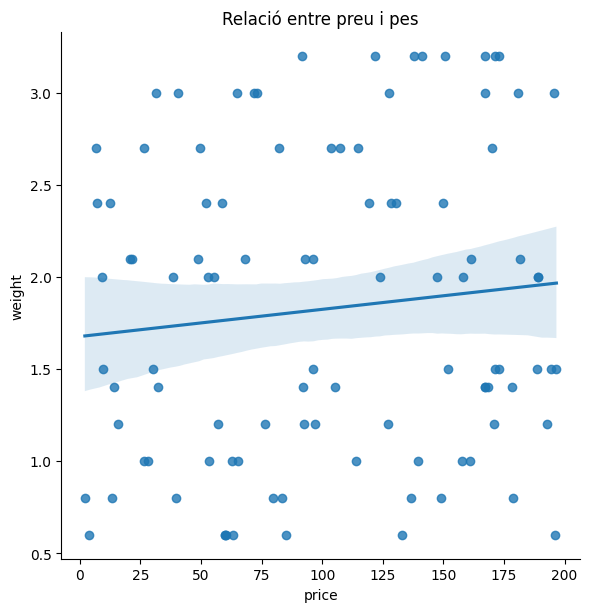

In [6]:
# Dues variables numèriques.
sns.lmplot(x="price",y='weight',data=df,height=6, aspect=1)
plt.title('Relació entre preu i pes')


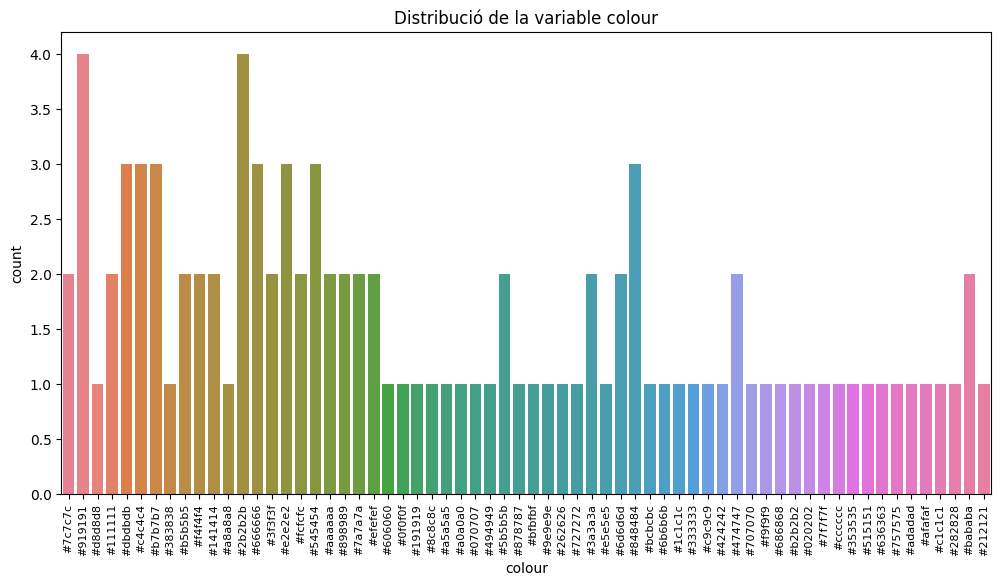

In [7]:
#Una variable categòrica.
plt.figure(figsize=(12, 6)) 
sns.countplot(x='colour',data=df,hue='colour')
plt.title('Distribució de la variable colour')
plt.xticks(rotation=90,fontsize=8);


Text(0.5, 1.0, 'vendes:declined o no')

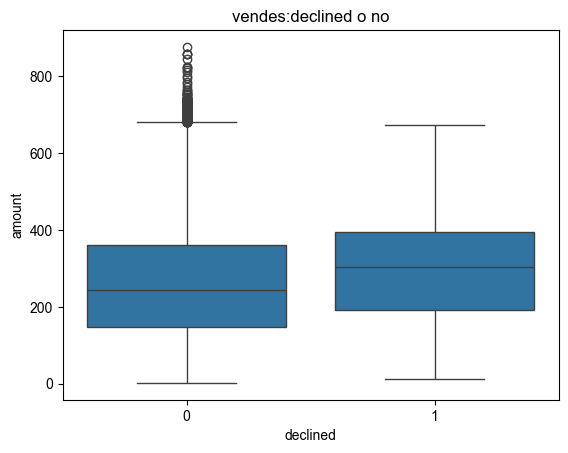

In [8]:
#Una variable categòrica i una numèrica.
df=dfs['transactions']
sns.boxplot( x="declined", y="amount",data=df)
sns.set_style("whitegrid") # estil de fons 
sns.set_palette("Set2") # paleta de colors suau
plt.title('vendes:declined o no')



In [9]:
df.columns

Index(['id', 'card_id', 'company_id', 'timestamp', 'amount', 'declined',
       'product_ids', 'user_id', 'lat', 'longitude'],
      dtype='object')

C:\Users\Portátil\AppData\Local\Temp\ipykernel_18836\2611337148.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='company_id', y='user_id', data=df_clients, palette='tab20')


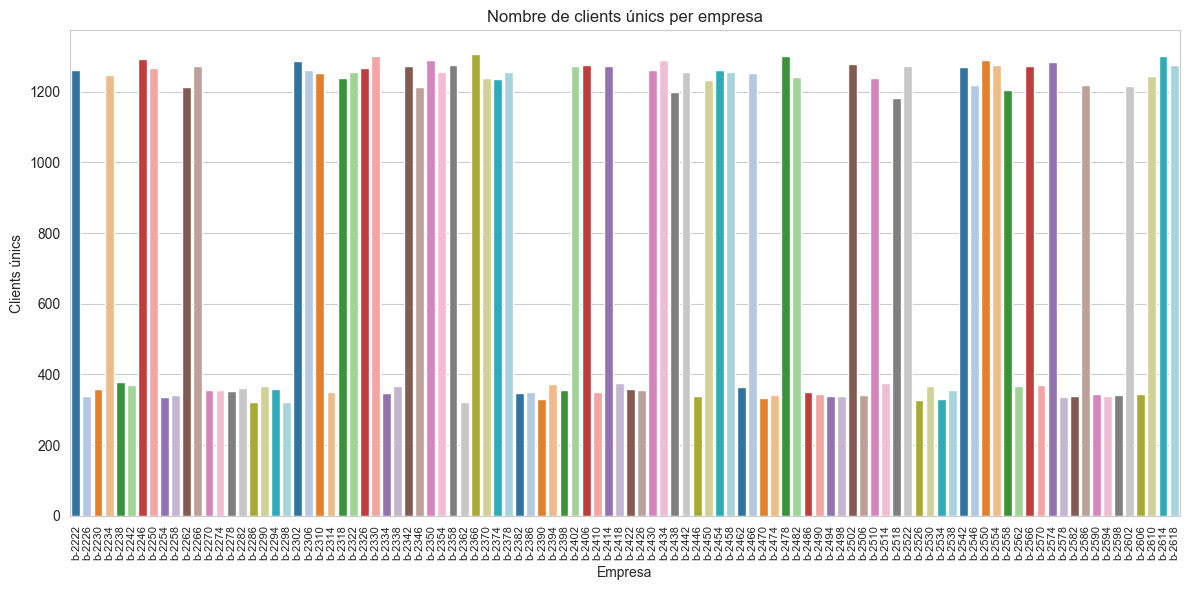

In [10]:
#Dues variables categòriques.
df = dfs['transactions']
df_clients = df.groupby('company_id')['user_id'].nunique().reset_index()
plt.figure(figsize=(12,6))
sns.barplot(x='company_id', y='user_id', data=df_clients, palette='tab20')
plt.xticks(rotation=90, fontsize=8)
plt.title('Nombre de clients únics per empresa')
plt.xlabel('Empresa')
plt.ylabel('Clients únics')
plt.tight_layout() 
plt.show()

In [11]:
df=dfs['transactions']

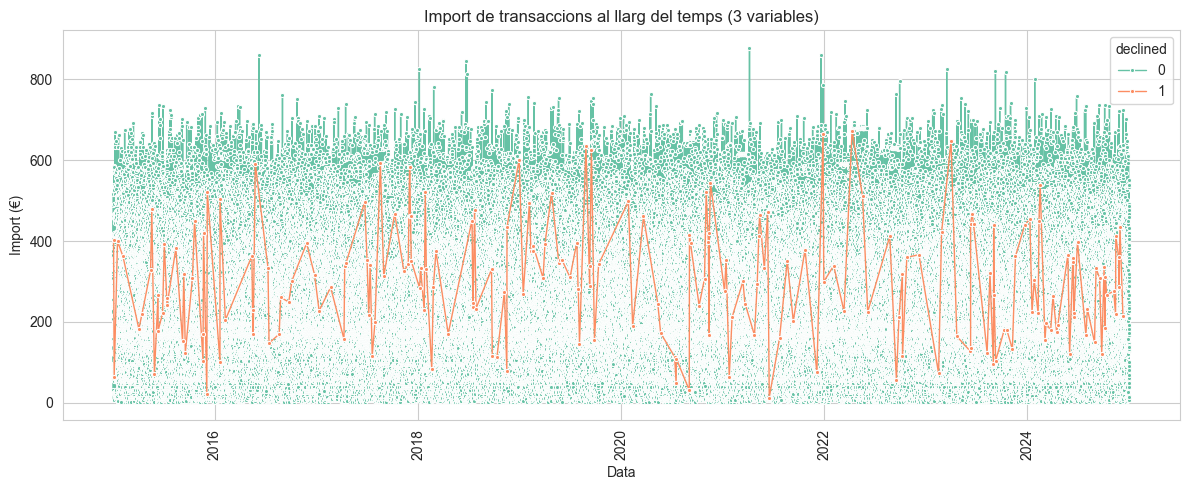

In [12]:
#Tres variables combinades.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df['timestamp'] = pd.to_datetime(df['timestamp'])

plt.figure(figsize=(12,5))
sns.lineplot(data=df,x='timestamp',y='amount',hue='declined',estimator=None,lw=1,marker='o',markersize=3)# molt important: NO agrega
plt.title("Import de transaccions al llarg del temps (3 variables)")
plt.xlabel("Data")
plt.ylabel("Import (€)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


In [ ]:
#decideixò fer el gràfic pairplot amb la taula Transactions i products per tenir mes variables.
# Miro types de les dades
df=dfs['transactions']
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   id           100000 non-null  object        
 1   card_id      100000 non-null  object        
 2   company_id   100000 non-null  object        
 3   timestamp    100000 non-null  datetime64[ns]
 4   amount       100000 non-null  float64       
 5   declined     100000 non-null  int64         
 6   product_ids  100000 non-null  object        
 7   user_id      100000 non-null  int64         
 8   lat          100000 non-null  object        
 9   longitude    100000 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(6)
memory usage: 7.6+ MB


In [14]:
## convertir en numerics les variables (lat, longuitude) per fer el gràfic i tenir més vble. núneriques.
df['lat'] = pd.to_numeric(df['lat'], errors='coerce')
df['longitude'] = pd.to_numeric(df['longitude'], errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   id           100000 non-null  object        
 1   card_id      100000 non-null  object        
 2   company_id   100000 non-null  object        
 3   timestamp    100000 non-null  datetime64[ns]
 4   amount       100000 non-null  float64       
 5   declined     100000 non-null  int64         
 6   product_ids  100000 non-null  object        
 7   user_id      100000 non-null  int64         
 8   lat          100000 non-null  float64       
 9   longitude    100000 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(2), object(4)
memory usage: 7.6+ MB


In [15]:
##de taula :transactions, tenim column: products_ids es object canviem per fer "join" amb id (numeric)
df['product_ids'] = pd.to_numeric(df['product_ids'], errors='coerce')


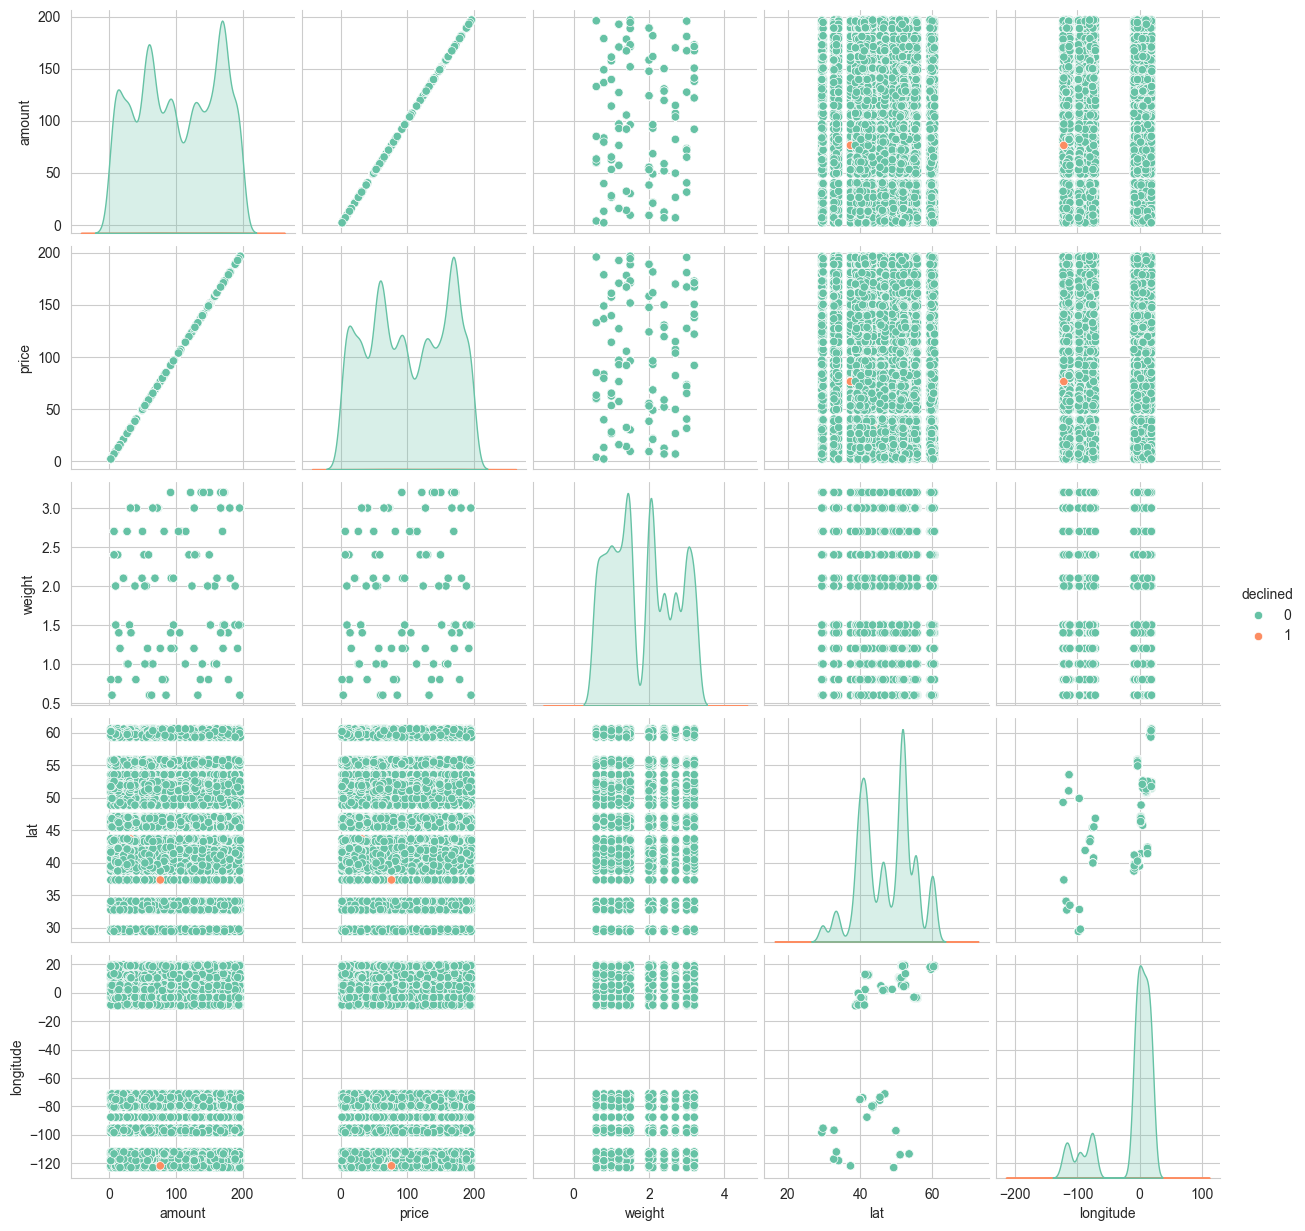

In [16]:
#faig un merge per poder treballar amb les variables de les dues taules
# de variable numeriques:amount','price','weight,'lat','langitude', per tenir un exemple més ampli.
df = dfs['transactions'].merge(
    dfs['products'][['id','price','weight']],
    left_on='product_ids',
    right_on='id',
    how='left'
)
sns.pairplot(df[['amount','price','weight','lat','longitude','declined']].dropna(), hue='declined')


Nivell 2
•	1. Representa la correlació d'algunes variables i interpreta els resultats segons les teves dades.
•	2. Implementa un Jointplot per explorar la relació entre dues variables i interpreta els resultats segons les teves dades.

 1. Representa la correlació d'algunes variables i interpreta els resultats segons les teves dades.

In [17]:
#miro tipos de dades
df.dtypes

id_x                   object
card_id                object
company_id             object
timestamp      datetime64[ns]
amount                float64
declined                int64
product_ids           float64
user_id                 int64
lat                   float64
longitude             float64
id_y                  float64
price                 float64
weight                float64
dtype: object

In [18]:
df[['price','weight']].corr()

,price,weight
price,1.000000,0.106581
weight,0.106581,1.000000


<Axes: >

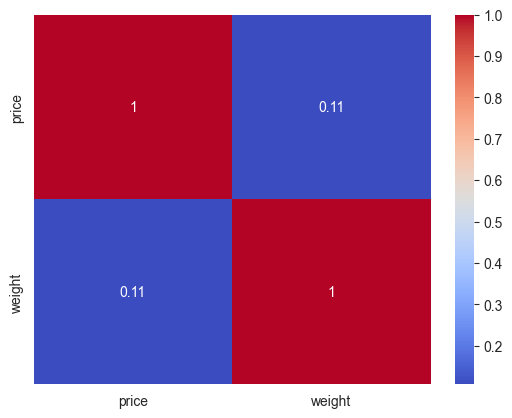

In [19]:
sns.heatmap(df[['price','weight']].corr(),annot=True,cmap="coolwarm")

2. Implementa un Jointplot per explorar la relació entre dues variables i interpreta els resultats segons les teves dades.

In [20]:
df=dfs['transactions']

In [21]:
df.columns

Index(['id', 'card_id', 'company_id', 'timestamp', 'amount', 'declined',
       'product_ids', 'user_id', 'lat', 'longitude'],
      dtype='object')

In [ ]:
# miro quantes files
df.shape

(100000, 10)

In [ ]:
#masses files es molt lent
#sns.jointplot(data=df, x="lat", y="amount", kind="scatter")

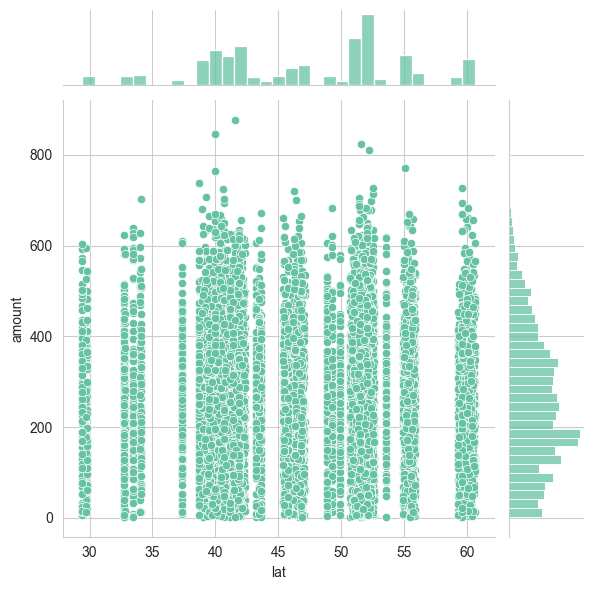

In [23]:
df_sample = df.sample(n=10000, random_state=42)# selecciona una mostra aleatòria de 10.000 files del DataFrame original df.
sns.jointplot(data=df_sample, x="lat", y="amount", kind="scatter")
